**Unsupervised Learning**

In [26]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples = 1000,centers = 2, n_features=2,  random_state =23)

In [51]:
X.shape

(1000, 2)

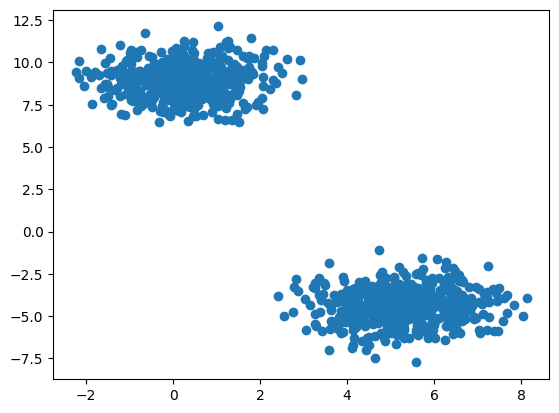

In [52]:
plt.scatter(X[:, 0], X[:, 1])

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
from sklearn.cluster import KMeans

**Manually select k values by
 - Elbow method

In [33]:
wcss = []
for k in range (1,11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [34]:
wcss

[2000.0000000000011,
 499.94518824159684,
 80.2994802166004,
 70.20748703409565,
 65.30773040460481,
 49.953432001203566,
 45.24479873915792,
 40.589581827307455,
 38.44069520480045,
 33.41912341836549]

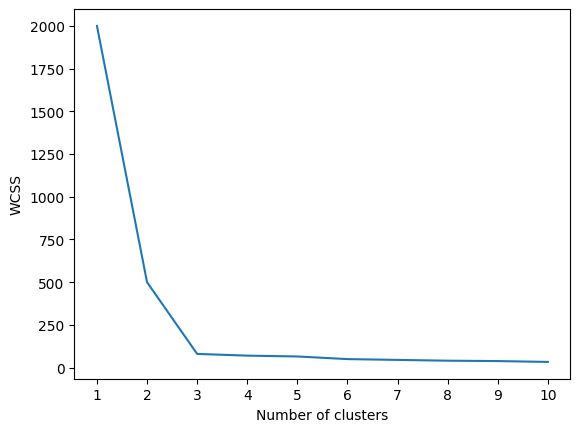

In [35]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [36]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++')
y_labels = kmeans.fit_predict(X)


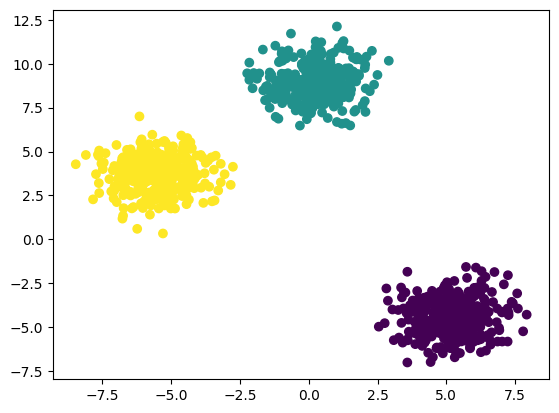

In [38]:
plt.scatter(X[:, 0], X[:, 1], c=y_labels)

**Knee Locator**

In [39]:
from kneed import KneeLocator

In [40]:
kl = KneeLocator(range(1,11), wcss, curve = 'convex', direction = 'decreasing')
kl.elbow

np.int64(3)

**Silhouette score**

In [41]:
from sklearn.metrics import silhouette_score
silhouette_coefficients = []
for k in range (2, 11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [42]:
silhouette_coefficients

[0.7148516660874806,
 0.8061084482498836,
 0.6445315619406277,
 0.47857994605248605,
 0.334774220569079,
 0.47677488126373724,
 0.3404333358253307,
 0.3421219240885021,
 0.3407740857310532]

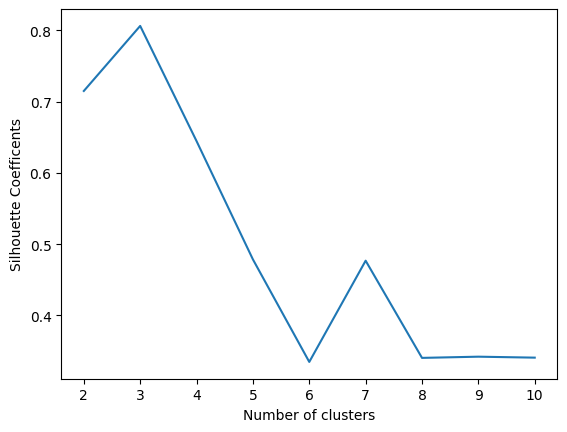

In [43]:
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficents')    
plt.show()